In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
ratings = pd.read_csv('ratings.csv')
movies  = pd.read_csv('movies.csv')

print('Ratings shape:', ratings.shape)
print('Movies shape :', movies.shape)
ratings.head()

Ratings shape: (100836, 4)
Movies shape : (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [3]:
data = ratings.merge(movies[['movieId', 'title']], on='movieId')

movie_counts = data['movieId'].value_counts()
user_counts  = data['userId'].value_counts()

data = data[
    data['movieId'].isin(movie_counts[movie_counts >= 50].index) &
    data['userId'].isin(user_counts[user_counts   >= 20].index)
]

print(f'Filtered: {data["userId"].nunique()} users, {data["movieId"].nunique()} movies')

item_user = data.pivot_table(index='title', columns='userId', values='rating').fillna(0)

print('Item-User Matrix shape:', item_user.shape)
item_user.iloc[:5, :5]

Filtered: 606 users, 450 movies
Item-User Matrix shape: (450, 606)


userId,1,2,3,4,5
title,,,,,
10 Things I Hate About You (1999),0.0,0.0,0.0,0.0,0.0
12 Angry Men (1957),0.0,0.0,0.0,5.0,0.0
2001: A Space Odyssey (1968),0.0,0.0,0.0,0.0,0.0
28 Days Later (2002),0.0,0.0,0.0,0.0,0.0
300 (2007),0.0,0.0,0.0,0.0,0.0


In [4]:
cosine_sim  = pd.DataFrame(cosine_similarity(item_user), index=item_user.index, columns=item_user.index)
pearson_sim = item_user.T.corr(method='pearson').fillna(0)

print('Cosine  sim shape:', cosine_sim.shape)
print('Pearson sim shape:', pearson_sim.shape)

Cosine  sim shape: (450, 450)
Pearson sim shape: (450, 450)


In [5]:
def get_similar_items(movie, sim_df, n=10):
    if movie not in sim_df.index:
        return pd.Series(dtype=float)
    return sim_df[movie].drop(movie).nlargest(n)

QUERY = 'Toy Story (1995)' if 'Toy Story (1995)' in item_user.index else item_user.index[0]

print(f'Top 10 similar to "{QUERY}" (Cosine):')
display(get_similar_items(QUERY, cosine_sim).reset_index().rename(columns={QUERY: 'Cosine Sim', 'title': 'Movie'}))

print(f'\nTop 10 similar to "{QUERY}" (Pearson):')
display(get_similar_items(QUERY, pearson_sim).reset_index().rename(columns={QUERY: 'Pearson Corr', 'title': 'Movie'}))

Top 10 similar to "Toy Story (1995)" (Cosine):


,Movie,Cosine Sim
0,Toy Story 2 (1999),0.572601
1,Jurassic Park (1993),0.565637
2,Independence Day (a.k.a. ID4) (1996),0.564262
3,Star Wars: Episode IV - A New Hope (1977),0.557388
4,Forrest Gump (1994),0.547096
5,"Lion King, The (1994)",0.541145
6,Star Wars: Episode VI - Return of the Jedi (1983),0.541089
7,Mission: Impossible (1996),0.538913
8,Groundhog Day (1993),0.534169
9,Back to the Future (1985),0.530381



Top 10 similar to "Toy Story (1995)" (Pearson):


,Movie,Pearson Corr
0,Toy Story 2 (1999),0.460814
1,Groundhog Day (1993),0.359957
2,Independence Day (a.k.a. ID4) (1996),0.356466
3,Willy Wonka & the Chocolate Factory (1971),0.355936
4,Mission: Impossible (1996),0.351107
5,"Nutty Professor, The (1996)",0.349343
6,"Bug's Life, A (1998)",0.344283
7,"Lion King, The (1994)",0.342378
8,Babe (1995),0.339665
9,"Monsters, Inc. (2001)",0.329237


In [6]:
def item_recommend(user_id, train_df, top_n=10, threshold=3.5):
    user_data    = train_df[train_df['userId'] == user_id]
    liked        = user_data[user_data['rating'] >= threshold]['title'].tolist()
    already_seen = set(user_data['title'])

    if not liked:
        liked = user_data.nlargest(5, 'rating')['title'].tolist()

    scores = {}
    for movie in liked:
        for sim_movie, score in get_similar_items(movie, cosine_sim).items():
            if sim_movie not in already_seen:
                scores[sim_movie] = scores.get(sim_movie, 0) + score

    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

for uid in data['userId'].unique()[:3]:
    print(f'\nUser {uid} – Top 5:')
    for rank, (movie, score) in enumerate(item_recommend(uid, data, top_n=5), 1):
        print(f'  {rank}. {movie[:55]}  ({score:.3f})')


User 1 – Top 5:
  1. Ferris Bueller's Day Off (1986)  (9.220)
  2. Aliens (1986)  (5.955)
  3. True Lies (1994)  (5.897)
  4. Breakfast Club, The (1985)  (4.703)
  5. Die Hard (1988)  (4.562)

User 2 – Top 5:
  1. Fight Club (1999)  (3.514)
  2. Batman Begins (2005)  (2.419)
  3. Social Network, The (2010)  (2.008)
  4. Avengers, The (2012)  (1.718)
  5. Grand Budapest Hotel, The (2014)  (1.604)

User 3 – Top 5:
  1. Big (1988)  (0.968)
  2. Wizard of Oz, The (1939)  (0.927)
  3. Star Wars: Episode I - The Phantom Menace (1999)  (0.901)
  4. When Harry Met Sally... (1989)  (0.892)
  5. Hook (1991)  (0.864)


In [7]:
def user_recommend(user_id, top_n=10):
    pivot     = data.pivot_table(index='userId', columns='title', values='rating').fillna(0)
    if user_id not in pivot.index:
        return []
    sim       = pd.DataFrame(cosine_similarity(pivot), index=pivot.index, columns=pivot.index)
    sim_users = sim[user_id].drop(user_id).nlargest(10).index
    unrated   = pivot.columns[pivot.loc[user_id] == 0]
    scores    = pivot.loc[sim_users, unrated].mul(sim.loc[sim_users, user_id], axis=0).sum()
    return scores.nlargest(top_n).index.tolist()

uid       = data['userId'].unique()[0]
item_recs = [r[0] for r in item_recommend(uid, data, top_n=10)]
user_recs = user_recommend(uid, top_n=10)

comparison = pd.DataFrame({'Rank': range(1, 11), 'Item-Based': item_recs, 'User-Based': user_recs})
print(f'Overlap: {len(set(item_recs) & set(user_recs))} movies in common')
display(comparison)

Overlap: 4 movies in common


,Rank,Item-Based,User-Based
0,1,Ferris Bueller's Day Off (1986),Aliens (1986)
1,2,Aliens (1986),Terminator 2: Judgment Day (1991)
2,3,True Lies (1994),Blade Runner (1982)
3,4,"Breakfast Club, The (1985)",Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
4,5,Die Hard (1988),"Christmas Story, A (1983)"
5,6,Terminator 2: Judgment Day (1991),"Sixth Sense, The (1999)"
6,7,"Shawshank Redemption, The (1994)",Die Hard (1988)
7,8,"Godfather, The (1972)",Gattaca (1997)
8,9,"Fifth Element, The (1997)",Star Trek II: The Wrath of Khan (1982)
9,10,Blade Runner (1982),Léon: The Professional (a.k.a. The Professiona...


In [8]:
train, test = train_test_split(data, test_size=0.2, random_state=42)

train_iu  = train.pivot_table(index='title', columns='userId', values='rating').fillna(0)
train_sim = pd.DataFrame(cosine_similarity(train_iu), index=train_iu.index, columns=train_iu.index)

sample = test.sample(300, random_state=42)
actuals, predicted = [], []

for _, row in sample.iterrows():
    movie, uid, actual = row['title'], row['userId'], row['rating']
    if movie not in train_sim.index:
        continue
    similar = get_similar_items(movie, train_sim, n=10)
    vals    = [train_iu.loc[sm, uid] * s for sm, s in similar.items()
               if sm in train_iu.index and uid in train_iu.columns and train_iu.loc[sm, uid] > 0]
    if vals:
        actuals.append(actual)
        predicted.append(np.mean(vals))

print(f'RMSE: {np.sqrt(mean_squared_error(actuals, predicted)):.4f}  (n={len(actuals)})')

RMSE: 2.1795  (n=283)


In [9]:
def precision_at_k(user_id, k=10, threshold=3.5):
    user_data = data[data['userId'] == user_id]
    if len(user_data) < 5:
        return 0.0

    train_u = user_data.sample(frac=0.8, random_state=42)
    test_u  = user_data.drop(train_u.index)

    recs         = item_recommend(user_id, train_u, top_n=k, threshold=threshold)
    rec_titles   = [r[0] for r in recs]
    ground_truth = set(test_u[test_u['rating'] >= threshold]['title'])

    if not rec_titles or not ground_truth:
        return 0.0

    return sum(1 for m in rec_titles if m in ground_truth) / k

eval_users   = data['userId'].unique()[:30]
K_VALUES     = [5, 10, 20]
prec_results = {k: np.mean([precision_at_k(u, k) for u in eval_users]) for k in K_VALUES}

print('Precision@K (avg over 30 users):')
for k, p in prec_results.items():
    print(f'  Precision@{k:2d}: {p:.4f}')

Precision@K (avg over 30 users):
  Precision@ 5: 0.4000
  Precision@10: 0.2967
  Precision@20: 0.2067


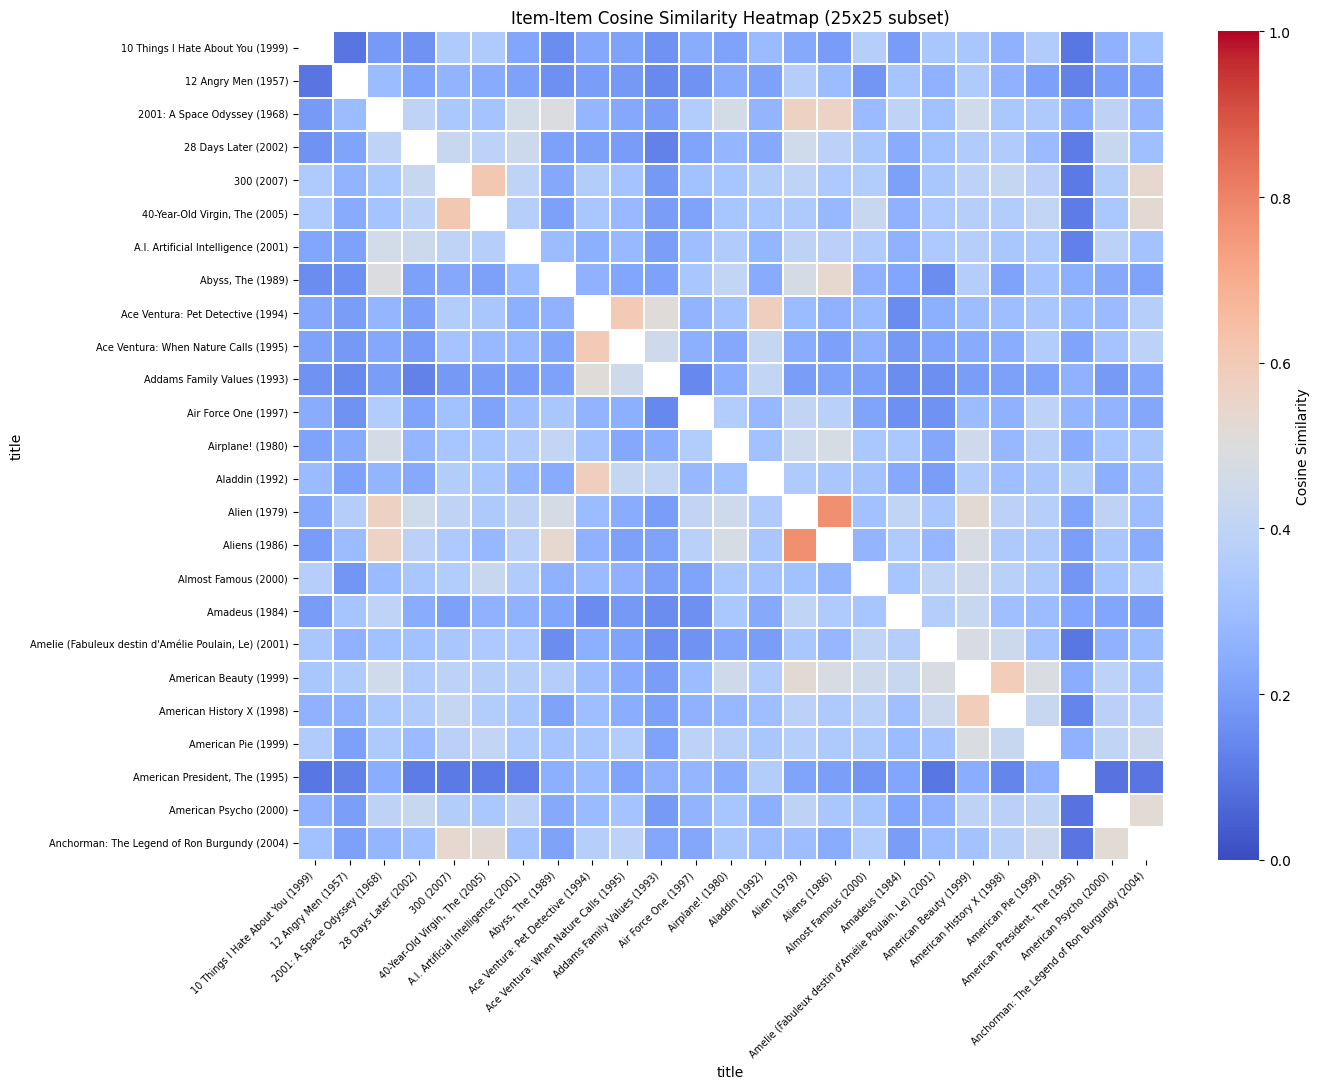

In [10]:
plt.figure(figsize=(14, 11))
sns.heatmap(
    cosine_sim.iloc[:25, :25],
    cmap='coolwarm', vmin=0, vmax=1,
    mask=np.eye(25, dtype=bool),
    linewidths=0.3, cbar_kws={'label': 'Cosine Similarity'}
)
plt.title('Item-Item Cosine Similarity Heatmap (25x25 subset)')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('item_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

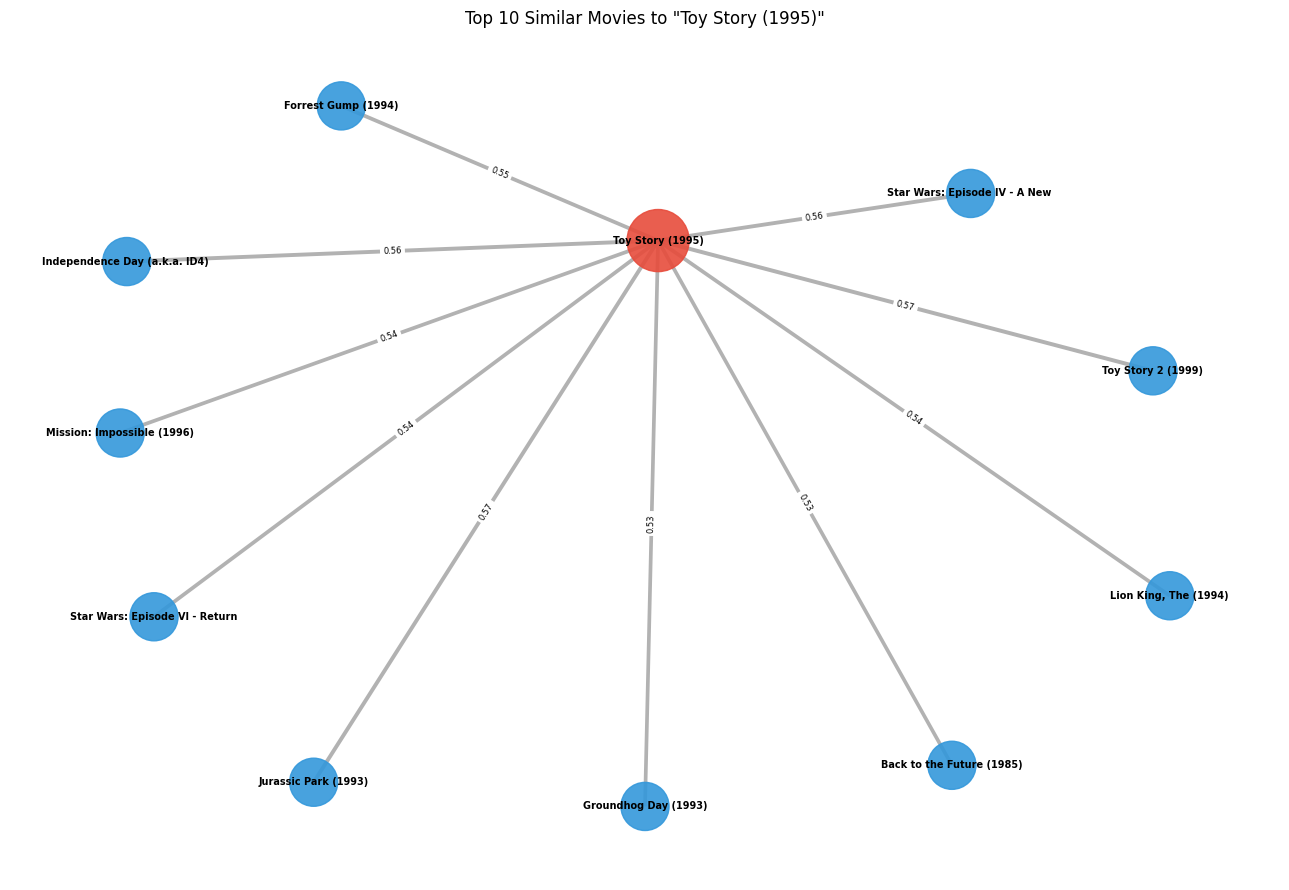

In [11]:
G       = nx.Graph()
top_sim = get_similar_items(QUERY, cosine_sim, n=10)
G.add_node(QUERY, node_type='query')

for movie, score in top_sim.items():
    G.add_node(movie[:30], node_type='similar')
    G.add_edge(QUERY, movie[:30], weight=score)

pos    = nx.spring_layout(G, seed=42, k=2.5)
colors = ['#e74c3c' if G.nodes[n]['node_type'] == 'query' else '#3498db' for n in G.nodes]
sizes  = [2000 if G.nodes[n]['node_type'] == 'query' else 1200 for n in G.nodes]

plt.figure(figsize=(13, 9))
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=[G[u][v]['weight']*5 for u,v in G.edges], alpha=0.6, edge_color='grey')
nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u,v): f"{G[u][v]['weight']:.2f}" for u,v in G.edges}, font_size=6)
plt.title(f'Top 10 Similar Movies to "{QUERY[:40]}"')
plt.axis('off')
plt.tight_layout()
plt.savefig('similar_items_graph.png', dpi=150, bbox_inches='tight')
plt.show()

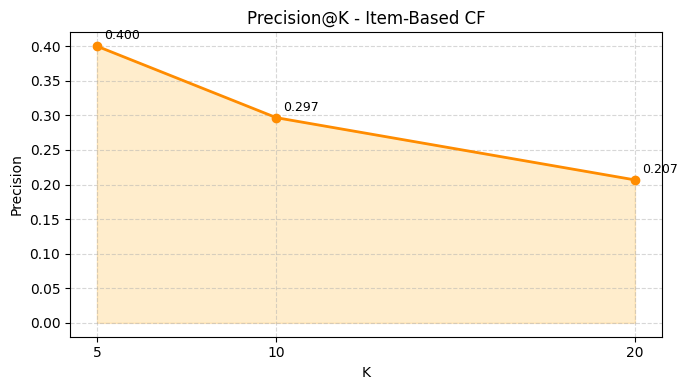

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(list(prec_results.keys()), list(prec_results.values()), marker='o', linewidth=2, color='darkorange')
plt.fill_between(list(prec_results.keys()), list(prec_results.values()), alpha=0.2, color='orange')
plt.title('Precision@K - Item-Based CF')
plt.xlabel('K')
plt.ylabel('Precision')
plt.xticks(K_VALUES)
plt.grid(True, linestyle='--', alpha=0.5)
for k, p in prec_results.items():
    plt.annotate(f'{p:.3f}', (k, p), textcoords='offset points', xytext=(5, 5), fontsize=9)
plt.tight_layout()
plt.savefig('precision_at_k.png', dpi=150, bbox_inches='tight')
plt.show()

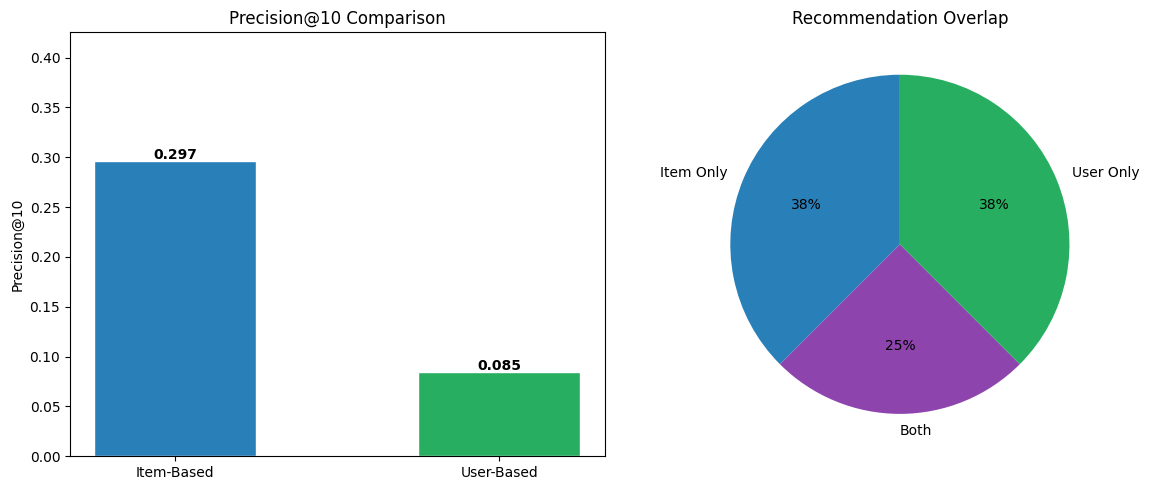

Item-Based Precision@10: 0.2967
User-Based Precision@10: 0.0850


In [13]:
def precision_at_k_user(user_id, k=10, threshold=3.5):
    user_data = data[data['userId'] == user_id]
    if len(user_data) < 5:
        return 0.0
    train_u = user_data.sample(frac=0.8, random_state=42)
    test_u  = user_data.drop(train_u.index)
    train_mat   = train_u.pivot_table(index='userId', columns='title', values='rating').fillna(0)
    other_users = data[data['userId'] != user_id].pivot_table(index='userId', columns='title', values='rating').fillna(0)
    full_train  = pd.concat([train_mat, other_users]).fillna(0)
    full_train  = full_train[~full_train.index.duplicated(keep='first')]
    sim = pd.DataFrame(cosine_similarity(full_train), index=full_train.index, columns=full_train.index)
    unrated = full_train.columns[full_train.loc[user_id] == 0]
    preds   = {m: (lambda r, s: np.dot(s[r!=0], r[r!=0]) / s[r!=0].sum() if (r!=0).sum() > 0 else np.nan)(
                   full_train.loc[sim[user_id].drop(user_id).nlargest(10).index, m].values,
                   sim[user_id].drop(user_id).nlargest(10).values)
               for m in unrated}
    preds = {m: v for m, v in preds.items() if v and not np.isnan(v)}
    rec_titles   = [m for m, _ in sorted(preds.items(), key=lambda x: x[1], reverse=True)[:k]]
    ground_truth = set(test_u[test_u['rating'] >= threshold]['title'])
    if not rec_titles or not ground_truth:
        return 0.0
    return sum(1 for m in rec_titles if m in ground_truth) / k

ub_precs  = [precision_at_k_user(u, 10) for u in eval_users[:20]]
prec_user = np.mean(ub_precs)
prec_item = prec_results[10]
overlap_n = len(set(item_recs) & set(user_recs))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(['Item-Based', 'User-Based'], [prec_item, prec_user],
                   color=['#2980b9', '#27ae60'], edgecolor='white', width=0.5)
axes[0].set_title('Precision@10 Comparison')
axes[0].set_ylabel('Precision@10')
axes[0].set_ylim(0, max(prec_item, prec_user) * 1.4 + 0.01)
for bar, val in zip(bars, [prec_item, prec_user]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center', fontweight='bold')

axes[1].pie(
    [len(item_recs)-overlap_n, overlap_n, len(user_recs)-overlap_n],
    labels=['Item Only', 'Both', 'User Only'],
    colors=['#2980b9', '#8e44ad', '#27ae60'],
    autopct='%1.0f%%', startangle=90
)
axes[1].set_title('Recommendation Overlap')
plt.tight_layout()
plt.savefig('cf_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Item-Based Precision@10: {prec_item:.4f}')
print(f'User-Based Precision@10: {prec_user:.4f}')

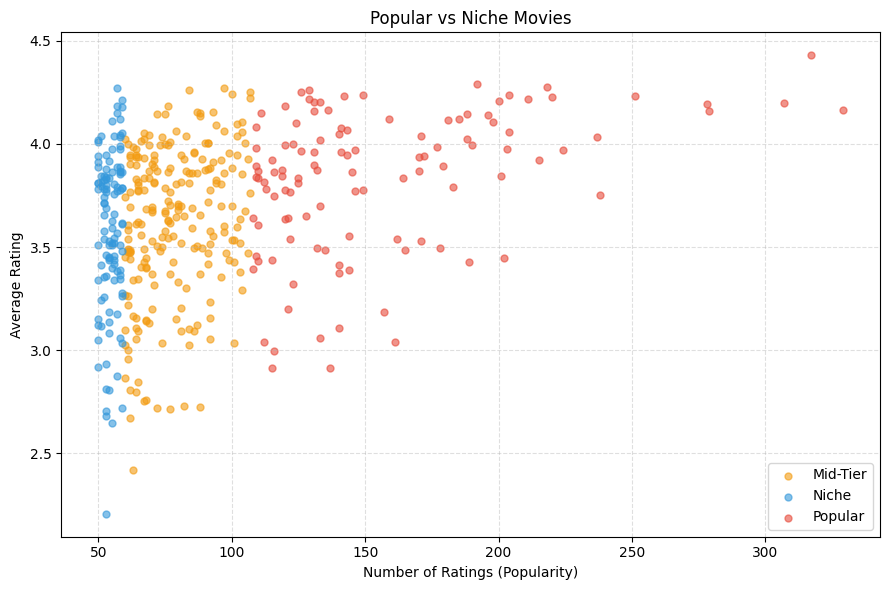

category
Mid-Tier    222
Niche       115
Popular     113
Name: count, dtype: int64


In [14]:
movie_stats = data.groupby('title').agg(count=('rating','count'), avg=('rating','mean')).reset_index()
p75 = movie_stats['count'].quantile(0.75)
p25 = movie_stats['count'].quantile(0.25)
movie_stats['category'] = movie_stats['count'].apply(
    lambda x: 'Popular' if x >= p75 else ('Niche' if x <= p25 else 'Mid-Tier')
)

palette = {'Popular':'#e74c3c', 'Mid-Tier':'#f39c12', 'Niche':'#3498db'}
plt.figure(figsize=(9, 6))
for cat, grp in movie_stats.groupby('category'):
    plt.scatter(grp['count'], grp['avg'], alpha=0.6, s=25, label=cat, color=palette[cat])

plt.title('Popular vs Niche Movies')
plt.xlabel('Number of Ratings (Popularity)')
plt.ylabel('Average Rating')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('popular_vs_niche.png', dpi=150, bbox_inches='tight')
plt.show()

print(movie_stats['category'].value_counts())